# `06_weight_diagnostics.ipynb` — can a gate beat the mean here, and where do the weights go?

Your run came back with the experts at AUC ≈ 0.83–0.86, the **naive mean at 0.904**, and every combiner
(supervised gate 0.896, unsupervised concept / Cell B 0.905, Cell A 0.875) sitting *on top of* the mean,
with patient-bootstrap CIs (≈0.82–0.97) that overlap almost completely. That is the classic ensemble
picture: averaging already beats the best single expert, and a router can only add value if (a) there is
**headroom** beyond the mean and (b) the **SQI predicts which expert to trust** on a given window.

This notebook answers four questions, in order — and the order matters, because each one gates the next:

1. **Headroom** — what is the *oracle* ceiling? If picking the best expert per window barely beats the mean,
   no router (and no extra feature) can help, and you should ship the mean.
2. **Routing signal** — does the unsupervised quality actually correlate with per-window expert correctness?
   This is the single number that says whether *more SQI features* could ever pay off.
3. **Is the gate even acting?** — weight distribution + effective number of experts. If the weights are
   near-uniform, the gate *is* the mean (which is why it matches it), and the fix is decisiveness, not data.
4. **Per-window inspector** — see expert probs, gate weights, quality and SQI for any window, and list the
   windows that actually matter.

It is self-contained (same setup + synthetic fallback as `05`), so it runs as-is; point Section 1 at your
data to get the real numbers. The diagnostic functions are written to drop straight into your `05` session
(they only need `lab, y, groups, P, SQI_ALL` and an `UnsupervisedGate`).

## 1 · Setup + data (identical to `05`; synthetic fallback if data absent)

In [9]:
import warnings; warnings.filterwarnings("ignore")
import sys, os
import numpy as np, pandas as pd, matplotlib.pyplot as plt

os.chdir('/home/nik/projects/BA')

REPO_SRC, DATA_ROOT = "src/", "data/patients"
AF_LIST, RESULTS_DIR = "data/AF_patients.txt", "results/06"
FS, WINDOW_SEC, HOP_SEC, BCG_MODE, RANDOM_STATE = 128, 30, 15, "wavelet", 0
EXCLUDE_PATIENTS = []
UW_METHOD, UW_BETA, UW_FLOOR = "pca", 4.0, 0.05
MODALITIES = ["cecg", "ppg", "bcg"]
os.makedirs(RESULTS_DIR, exist_ok=True); sys.path.append(REPO_SRC)

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import roc_auc_score, confusion_matrix
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture

try:
    import extract as X; HAVE_REPO = True
except Exception as e:
    HAVE_REPO = False; print("repo src not importable ->", e)

def synthetic_pipeline(n_pat=40, win=40, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    SIGS = {"cecg": ["cecg"], "ppg": ["ppg1", "ppg2"], "bcg": ["bcg1", "bcg2"]}
    rows, groups, ys, qual = [], [], [], []
    for pid in range(n_pat):
        af = pid % 2
        for w in range(win):
            rows.append(f"PAT{pid:03d}"); groups.append(pid); ys.append(af); qual.append(rng.uniform(0,1,3))
    qual = np.array(qual); N = len(ys); yv = np.array(ys)
    data = {"patient": rows, "win_idx": np.tile(np.arange(win), n_pat),
            "t_start_s": np.tile(np.arange(win)*HOP_SEC, n_pat), "AF": yv.astype(float), "y": yv.astype(float)}
    for j, m in enumerate(MODALITIES):
        for s in SIGS[m]:
            for k in ["kSQI","sSQI","pSQI","bSQI","tSQI"]:
                col = qual[:, j] + 0.25*rng.standard_normal(N); col[rng.random(N) < 0.04] = np.nan
                data[f"sqi_{s}_{k}"] = np.clip(col, 0, 1)
            data[f"sqi_{s}_composite"] = np.clip(qual[:, j] + 0.15*rng.standard_normal(N), 0, 1)
    lab = pd.DataFrame(data)
    sqi_all = [c for c in lab.columns if c.startswith("sqi_") and not c.endswith("_composite")]
    lab.attrs["_qual"] = qual
    return lab, sqi_all, {m: [] for m in MODALITIES}

if HAVE_REPO and os.path.exists(DATA_ROOT):
    cfg = X.ExtractConfig(data_root=DATA_ROOT, af_list=AF_LIST, fs=FS, window_s=WINDOW_SEC,
                          hop_s=HOP_SEC, bcg_mode=BCG_MODE, min_valid_hrv=0)
    lab = X.load_or_extract(cfg, RESULTS_DIR)
    if EXCLUDE_PATIENTS: lab = lab[~lab["patient"].isin(set(EXCLUDE_PATIENTS))].reset_index(drop=True)
    lab["y"] = lab["AF"].astype(float); lab = lab.dropna(subset=["y"]).reset_index(drop=True)
    SQI_ALL = X.gate_sqi_cols(lab, "all"); FEAT_COLS = {m: X.expert_feature_cols(lab, m) for m in MODALITIES}
    SYNTHETIC = False; print("REAL data:", lab.shape)
else:
    print("!!! SYNTHETIC FALLBACK — replace before reporting !!!")
    lab, SQI_ALL, FEAT_COLS = synthetic_pipeline(); SYNTHETIC = True

y = lab["y"].astype(int).values; groups = lab["patient"].values
if not SYNTHETIC:
    P = np.full((len(lab), 3), np.nan)
    for j, mod in enumerate(MODALITIES):
        Xm = lab[FEAT_COLS[mod]].to_numpy(float)
        for tr, te in LeaveOneGroupOut().split(Xm, y, groups):
            if len(np.unique(y[tr])) < 2: P[te, j] = y[tr].mean(); continue
            clf = HistGradientBoostingClassifier(random_state=RANDOM_STATE)
            clf.fit(Xm[tr], y[tr], sample_weight=compute_sample_weight("balanced", y[tr]))
            P[te, j] = clf.predict_proba(Xm[te])[:, 1]
else:
    rng = np.random.default_rng(1); qual = lab.attrs["_qual"]; N = len(y); P = np.zeros((N,3))
    for j in range(3):
        g = qual[:, j]; P[:, j] = np.clip(g*np.where(y==1,.85,.15)+(1-g)*rng.uniform(0,1,N), 1e-3, 1-1e-3)
print("per-expert AUC:", {m: round(roc_auc_score(y, P[:, j]),3) for j,m in enumerate(MODALITIES)},
      "| mean:", round(roc_auc_score(y, P.mean(1)),3))


Cache gefunden -> lade results/06/features_sqi_cecg_cwt_b84841.csv
REAL data: (4724, 192)
per-expert AUC: {'cecg': 0.846, 'ppg': 0.831, 'bcg': 0.859} | mean: 0.904


## 2 · Unsupervised core + gate (now exposing `.quality()` so we can inspect it)

In [10]:
def _prep(Xtr, Xte):
    with np.errstate(all="ignore"): med = np.nanmedian(Xtr, axis=0)
    med = np.where(np.isfinite(med), med, 0.0)
    Xtr = np.where(np.isfinite(Xtr), Xtr, med); Xte = np.where(np.isfinite(Xte), Xte, med)
    mu, sd = Xtr.mean(0), Xtr.std(0)+1e-8
    return (Xtr-mu)/sd, (Xte-mu)/sd
def _orient(s_tr, a_tr, *to):
    if np.std(s_tr) < 1e-9 or np.std(a_tr) < 1e-9: return to if len(to)>1 else to[0]
    sg = 1.0 if np.corrcoef(s_tr, a_tr)[0,1] >= 0 else -1.0
    o = tuple(sg*t for t in to); return o if len(o)>1 else o[0]
def _to_unit(ref, val):
    lo, hi = np.percentile(ref,5), np.percentile(ref,95)
    if hi-lo < 1e-9: return np.full_like(np.asarray(val,float), 0.5)
    return np.clip((val-lo)/(hi-lo), 0, 1)
def modality_quality(Xtr, Xte, a_tr, method=UW_METHOD):
    if Xtr.shape[1]==0: return _to_unit(a_tr,a_tr), np.full(len(Xte),0.5)
    Ztr, Zte = _prep(Xtr, Xte)
    if np.allclose(Ztr.std(0),0): return _to_unit(a_tr,a_tr), np.full(len(Xte),0.5)
    if method=="gmm":
        try:
            gm = GaussianMixture(2, covariance_type="diag", reg_covar=1e-4, random_state=RANDOM_STATE).fit(Ztr)
            a = a_tr - a_tr.mean(); direction = Ztr.T@a if np.std(a_tr)>1e-9 else Ztr.mean(0)
            cl = int(np.argmax(gm.means_@direction))
            r_tr, r_te = gm.predict_proba(Ztr)[:,cl], gm.predict_proba(Zte)[:,cl]
            r_tr, r_te = _orient(r_tr, a_tr, r_tr, r_te); return np.clip(r_tr,0,1), np.clip(r_te,0,1)
        except Exception: pass
    p = PCA(1, random_state=RANDOM_STATE).fit(Ztr)
    s_tr, s_te = p.transform(Ztr).ravel(), p.transform(Zte).ravel()
    s_tr, s_te = _orient(s_tr, a_tr, s_tr, s_te)
    return _to_unit(s_tr,s_tr), _to_unit(s_tr,s_te)
def weights_from_quality(Q, beta=UW_BETA, floor=UW_FLOOR):
    Q = np.asarray(Q,float); k = Q.shape[1]; z = beta*Q; z -= z.max(1,keepdims=True)
    e = np.exp(z); w = e/e.sum(1,keepdims=True); w = (1-floor*k)*w+floor; return w/w.sum(1,keepdims=True)

SIG_OF = {"cecg":["cecg"], "ppg":["ppg1","ppg2"], "bcg":["bcg1","bcg2"]}
# columns that are inherently cross-modal (not owned by any single modality) ->
# fed to all three learners as a shared "trust me vs. trust the others" signal
XMODAL = ["sqi_xmodal_n_agree", "sqi_xmodal_confidence", "sqi_xmodal_trustworthy"]

def modality_sqi_cols(cols, mod):
    """SQI inputs for ONE modality's unsupervised learner:
       its per-signal SQIs + its own inter-channel xcorr + the shared cross-modal SQIs."""
    own = [c for c in cols
           if any(c.startswith(f"sqi_{s}_") for s in SIG_OF[mod])   # sqi_cecg_/ppg1/ppg2/bcg1/bcg2_*
           or c.startswith(f"sqi_{mod}_xcorr")]                     # sqi_ppg_xcorr / sqi_bcg_xcorr
    return own + [c for c in XMODAL if c in cols]
def modality_anchor(df, mod):
    comps = [f"sqi_{s}_composite" for s in SIG_OF[mod] if f"sqi_{s}_composite" in df.columns]
    if comps: return np.nan_to_num(df[comps].to_numpy(float).mean(1), nan=0.5)
    mc = modality_sqi_cols(SQI_ALL, mod)
    return np.nan_to_num(df[mc].to_numpy(float).mean(1), nan=0.5) if mc else np.full(len(df),0.5)

class UnsupervisedGate:
    def __init__(self, scope="per_modality", method=UW_METHOD, beta=UW_BETA, floor=UW_FLOOR):
        self.scope, self.method, self.beta, self.floor = scope, method, beta, floor
    def fit(self, df_tr):
        self._cols = {m: modality_sqi_cols(SQI_ALL, m) for m in MODALITIES}
        self._anchor_tr = {m: modality_anchor(df_tr, m) for m in MODALITIES}
        self._train_df = df_tr; return self
    def quality(self, df_te):
        Q = np.zeros((len(df_te), len(MODALITIES)))
        for j, m in enumerate(MODALITIES):
            Xtr = self._train_df[self._cols[m]].to_numpy(float); Xte = df_te[self._cols[m]].to_numpy(float)
            _, q = modality_quality(Xtr, Xte, self._anchor_tr[m], self.method); Q[:, j] = q
        return Q
    def weights(self, df_te): return weights_from_quality(self.quality(df_te), self.beta, self.floor)
    def predict_proba(self, df_te, P_te): return (self.weights(df_te)*P_te).sum(1)

def lopo_collect(scope="per_modality", beta=UW_BETA, floor=UW_FLOOR, method=UW_METHOD):
    """Returns OOF blended prob, OOF weights W (N,3), OOF quality Q (N,3)."""
    bl3 = np.full(len(lab), np.nan); W = np.zeros((len(lab),3)); Q = np.zeros((len(lab),3))
    for tr, te in LeaveOneGroupOut().split(lab, y, groups):
        g = UnsupervisedGate(scope, method, beta, floor).fit(lab.iloc[tr])
        Q[te] = g.quality(lab.iloc[te]); W[te] = weights_from_quality(Q[te], beta, floor)
        bl3[te] = (W[te]*P[te]).sum(1)
    return bl3, W, Q

blended, W, Q = lopo_collect("per_modality")
print("gate AUC:", round(roc_auc_score(y, blended),3), "| mean AUC:", round(roc_auc_score(y, P.mean(1)),3))


gate AUC: 0.903 | mean AUC: 0.904


## 3 · Q1 — Headroom: the oracle ceiling

`oracle_select` peeks at the labels and picks, for each window, the expert whose probability is closest to
the truth. **It is not achievable** — it is the absolute ceiling any selector/router could reach. Read it
like this:

- `oracle_select ≈ naive_mean` → **no routing headroom.** No gate and no extra SQI feature can beat the
  mean; the honest move is to report the mean. (This is the most likely outcome given your numbers.)
- `oracle_select ≫ naive_mean` → headroom exists; the bottleneck is whether SQI can *predict* the routing
  (Q2), not the combiner architecture.

In [11]:
def oracle_ceiling(y, P):
    pick = np.argmin(np.abs(P - y[:, None]), axis=1)
    p_or = P[np.arange(len(y)), pick]
    return dict(best_single=round(max(roc_auc_score(y, P[:,j]) for j in range(P.shape[1])),3),
                naive_mean=round(roc_auc_score(y, P.mean(1)),3),
                oracle_select=round(roc_auc_score(y, p_or),3))
oc = oracle_ceiling(y, P)
print(oc)
gap = oc["oracle_select"] - oc["naive_mean"]
print(f"\nHEADROOM (oracle - mean) = {gap:+.3f}  ->",
      "negligible: ship the mean" if gap < 0.02 else
      "some: worth chasing if Q2 shows signal" if gap < 0.06 else "substantial: routing can pay off")


{'best_single': 0.859, 'naive_mean': 0.904, 'oracle_select': 0.992}

HEADROOM (oracle - mean) = +0.088  -> substantial: routing can pay off


## 4 · Q2 — Routing signal: does SQI quality predict which expert is right?

This is the number that decides whether **more SQI features** are worth it. For each modality we correlate
the OOF unsupervised quality `q_m` with that expert's per-window correctness `1−|p_m−y|`, and we check how
often the highest-quality modality is actually the best expert (vs. the 1/3 chance rate).

- correlations near 0 and pick-rate near chance → SQI carries little routing information; adding more
  *single-signal* SQIs (more kSQI/pSQI variants) will not help. The lever is **different** features
  (cross-modal agreement), not more of the same.
- clearly positive correlations → the signal exists; raise decisiveness (Q3) and add routing-oriented
  features.

{'corr[cecg]': 0.035, 'corr[ppg]': 0.38, 'corr[bcg]': 0.09, 'quality_picks_best': 0.454, 'chance': 0.333, 'mean_|corr|': 0.168}

VERDICT: real routing signal


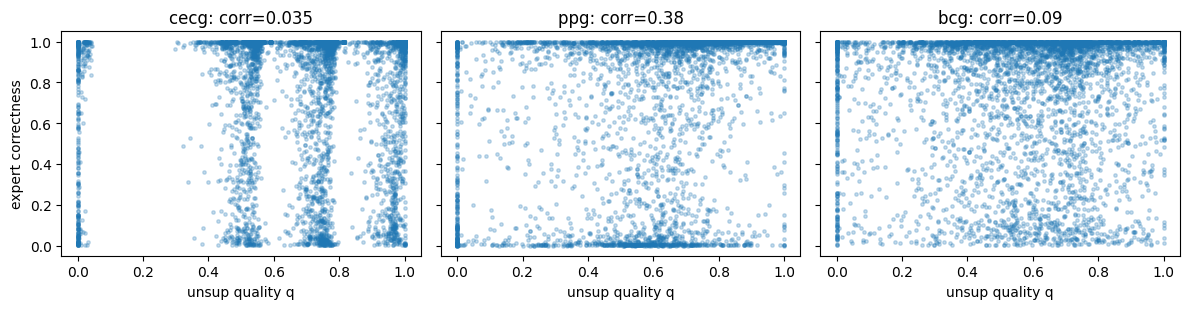

In [12]:
def routing_signal(y, P, Q):
    out = {}; corrs = []
    for j, m in enumerate(MODALITIES):
        c = 1 - np.abs(P[:, j] - y)
        cc = np.corrcoef(Q[:, j], c)[0, 1] if np.std(Q[:,j])>1e-9 else 0.0
        corrs.append(cc); out[f"corr[{m}]"] = round(float(cc), 3)
    best = np.argmin(np.abs(P - y[:, None]), 1)
    out["quality_picks_best"] = round(float((Q.argmax(1) == best).mean()), 3)
    out["chance"] = round(1/len(MODALITIES), 3)
    out["mean_|corr|"] = round(float(np.mean(np.abs(corrs))), 3)
    return out
rs = routing_signal(y, P, Q); print(rs)
verdict = ("no usable routing signal in current SQI" if rs["mean_|corr|"] < 0.05
           else "weak routing signal" if rs["mean_|corr|"] < 0.15 else "real routing signal")
print("\nVERDICT:", verdict)

# visual: quality vs correctness per modality
fig, ax = plt.subplots(1, 3, figsize=(12, 3.2), sharey=True)
for j, m in enumerate(MODALITIES):
    c = 1 - np.abs(P[:, j] - y)
    ax[j].scatter(Q[:, j], c, s=6, alpha=.25)
    ax[j].set_title(f"{m}: corr={rs[f'corr[{m}]']}"); ax[j].set_xlabel("unsup quality q")
ax[0].set_ylabel("expert correctness"); plt.tight_layout(); plt.show()


## 5 · Q3 — Is the gate even acting, or is it just the mean in disguise?

If the weights sit near `(1/3, 1/3, 1/3)`, the blend *is* the mean — which explains a gate that "matches
the mean." The **effective number of experts** = `exp(entropy(w))` makes this concrete: ≈3 means uniform
(no routing), ≈1 means it commits to one expert per window. If Q2 showed signal but `eff_experts≈3`, the
fix is more decisiveness (raise `UW_BETA`, lower `UW_FLOOR`) — the sweep in Section 7 does this safely.

{'mean_weight': {'cecg': 0.366, 'ppg': 0.358, 'bcg': 0.276}, 'weight_std': {'cecg': 0.117, 'ppg': 0.152, 'bcg': 0.104}, 'eff_experts_mean': 2.778, 'eff_experts_p10': 2.499, 'max_weight_mean': 0.482}


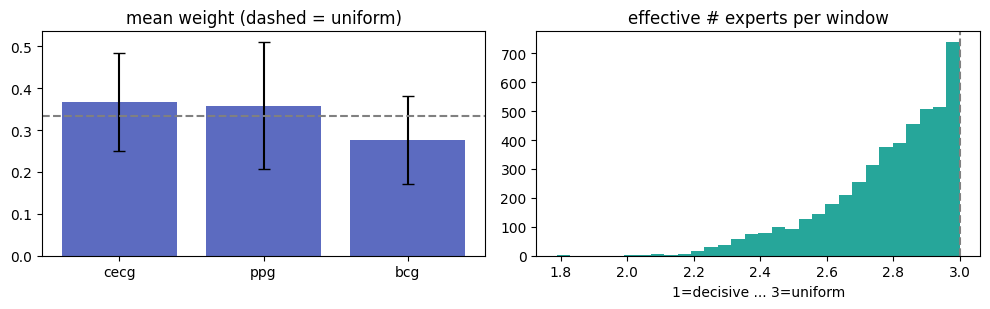

In [13]:
def weight_diagnostics(W):
    eps = 1e-9; ent = -(W*np.log(W+eps)).sum(1); eff = np.exp(ent)
    return dict(mean_weight={m: round(float(W[:,j].mean()),3) for j,m in enumerate(MODALITIES)},
                weight_std={m: round(float(W[:,j].std()),3) for j,m in enumerate(MODALITIES)},
                eff_experts_mean=round(float(eff.mean()),3),
                eff_experts_p10=round(float(np.percentile(eff,10)),3),
                max_weight_mean=round(float(W.max(1).mean()),3))
wd = weight_diagnostics(W); print(wd)

fig, ax = plt.subplots(1, 2, figsize=(10, 3.2))
ax[0].bar(MODALITIES, [wd["mean_weight"][m] for m in MODALITIES],
          yerr=[wd["weight_std"][m] for m in MODALITIES], capsize=4, color="#5c6bc0")
ax[0].axhline(1/3, ls="--", c="grey"); ax[0].set_title("mean weight (dashed = uniform)")
eff = np.exp(-(W*np.log(W+1e-9)).sum(1))
ax[1].hist(eff, bins=30, color="#26a69a"); ax[1].axvline(3, ls="--", c="grey")
ax[1].set_title("effective # experts per window"); ax[1].set_xlabel("1=decisive ... 3=uniform")
plt.tight_layout(); plt.show()


## 6 · Q4 — Per-window inspector + the windows that actually matter

A gate can only help where experts **disagree**. `disagreement_gain` restricts the AUC to the most
disagreeing windows and compares gate vs mean there. `inspect_window` shows everything for one window;
`top_routing_targets` lists the windows where routing *could* flip the decision (high disagreement, the mean
is wrong, but at least one expert is right) — the rows to read by hand.

disagreement: {'frac': 0.3, 'mean_auc_disagree': 0.8, 'gate_auc_disagree': 0.779}

Windows where routing COULD flip the call (mean wrong, an expert right):


,patient,win_idx,disagreement,truth,mean_p,gate_p,gate_fixes
1266,PAT012,108,0.467,0,0.662,0.462,True
1141,PAT011,102,0.466,0,0.666,0.666,False
228,PAT004,22,0.466,0,0.661,0.562,False
999,PAT010,79,0.466,0,0.664,0.700,False
224,PAT004,18,0.463,0,0.666,0.572,False
1261,PAT012,103,0.462,0,0.654,0.479,True
1851,PAT017,98,0.460,0,0.657,0.419,True
3397,PAT033,101,0.460,1,0.340,0.361,False
1157,PAT011,118,0.460,0,0.668,0.898,False
1151,PAT011,112,0.459,0,0.674,0.651,False



Example — worst-predicted window:
patient=PAT042 win_idx=93 TRUE=non-AF
  expert P(AF): cecg=1.00  ppg=1.00  bcg=0.99
  unsup qual  : cecg=0.75  ppg=0.64  bcg=0.73
  gate weight : cecg=0.38  ppg=0.27  bcg=0.35
  blended     : 1.00 -> AF   mean=1.00


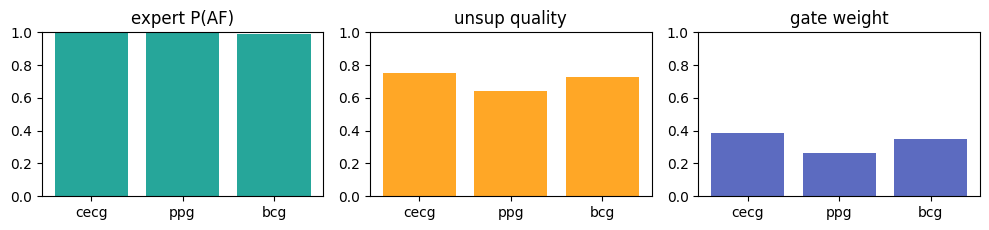

In [14]:
def disagreement_gain(y, P, blended, frac=0.3):
    d = P.std(1); hi = d >= np.quantile(d, 1-frac); ok = (y[hi].sum()>0 and y[hi].sum()<hi.sum())
    return dict(frac=round(float(hi.mean()),3),
                mean_auc_disagree=round(roc_auc_score(y[hi], P[hi].mean(1)),3) if ok else None,
                gate_auc_disagree=round(roc_auc_score(y[hi], blended[hi]),3) if ok else None)
print("disagreement:", disagreement_gain(y, P, blended))

def inspect_window(pid=None, win_idx=None, row=None):
    if row is None:
        sel = lab.index[(lab.patient==pid) & (lab.win_idx==win_idx)]
        if len(sel)==0: print("no such window"); return
        row = int(sel[0])
    r = lab.iloc[row]
    print(f"patient={r.patient} win_idx={int(r.win_idx)} TRUE={'AF' if y[row]==1 else 'non-AF'}")
    print("  expert P(AF):", "  ".join(f"{m}={P[row,j]:.2f}" for j,m in enumerate(MODALITIES)))
    print("  unsup qual  :", "  ".join(f"{m}={Q[row,j]:.2f}" for j,m in enumerate(MODALITIES)))
    print("  gate weight :", "  ".join(f"{m}={W[row,j]:.2f}" for j,m in enumerate(MODALITIES)))
    print(f"  blended     : {blended[row]:.2f} -> {'AF' if blended[row]>=.5 else 'non-AF'}"
          f"   mean={P[row].mean():.2f}")
    fig, ax = plt.subplots(1, 3, figsize=(10, 2.4))
    for a, vals, t, c in zip(ax, [P[row], Q[row], W[row]],
                             ["expert P(AF)","unsup quality","gate weight"], ["#26a69a","#ffa726","#5c6bc0"]):
        a.bar(MODALITIES, vals, color=c); a.set_ylim(0,1); a.set_title(t)
    plt.tight_layout(); plt.show()

def top_routing_targets(n=12):
    d = P.std(1); mean_wrong = (np.abs(P.mean(1)-y) > 0.5)
    any_right = (np.abs(P - y[:, None]) < 0.5).any(1)
    cand = mean_wrong & any_right
    df = lab.loc[cand, ["patient","win_idx"]].copy()
    df["disagreement"] = d[cand]; df["truth"] = y[cand]; df["mean_p"] = P.mean(1)[cand]
    df["gate_p"] = blended[cand]; df["gate_fixes"] = (np.abs(blended[cand]-y[cand]) < 0.5)
    return df.sort_values("disagreement", ascending=False).head(n).round(3)

print("\nWindows where routing COULD flip the call (mean wrong, an expert right):")
display(top_routing_targets())
print("\nExample — worst-predicted window:")
inspect_window(row=int(np.argmax(np.abs(blended - y))))


## 7 · Decisiveness sweep + the "more SQI features" experiment

**Sweep `UW_BETA`/`UW_FLOOR`.** If Q2 found signal, more decisive weights should raise AUC; if not, they
will *lower* it (you're amplifying noise). Either way the curve tells you the truth — never hand-pick beta
on the full set; wrap it in nested LOPO before reporting.

**More SQI features — the honest answer.** Adding more *single-signal* SQIs (more kurtosis/power variants)
mostly adds correlated copies of what you have; it won't create routing signal that Q2 says isn't there.
What *can* help are **routing-oriented** features that measure agreement *between* modalities — exactly the
signal a router needs:

- **Cross-modal HR agreement** (`sqi_xmodal_*`) and **inter-channel xcorr** (`sqi_<mod>_xcorr`) — already in
  `extract.py`'s feature writer. Your table shows 25 SQI inputs (5 signals × 5 SQIs), so these are **not
  currently in your cache**. Re-extract with them and they flow into the gate automatically.
- **Temporal neighbour context** (`extract.add_neighbor_context`) — appends each window's prev/next SQI, so
  the gate can smooth weights over time (AF persists across windows).

The cell below quantifies the ceiling these could reach *before* you spend extraction time: it asks how well
the SQI predicts per-window expert correctness with a proper supervised probe (LOPO). If that probe is near
chance, the features aren't the bottleneck — patient count and the weak label-routing signal are.

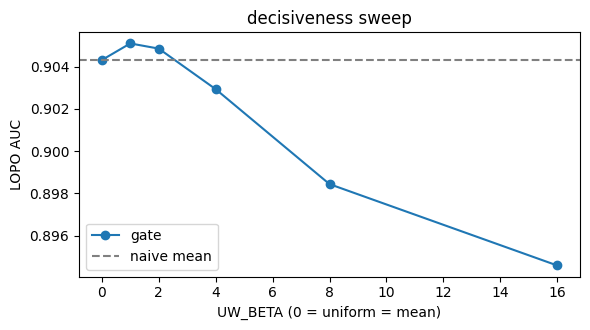

beta sweep AUC: {0: np.float64(0.904), 1: np.float64(0.905), 2: np.float64(0.905), 4: np.float64(0.903), 8: np.float64(0.898), 16: np.float64(0.895)} | mean: 0.904


In [ ]:
# 7a — decisiveness sweep (per_modality gate)
betas = [0, 1, 2, 4, 8, 16]
sweep = []
for b in betas:
    bl, _, _ = lopo_collect("per_modality", beta=float(b))
    sweep.append(roc_auc_score(y, bl))
mean_auc = roc_auc_score(y, P.mean(1))
plt.figure(figsize=(6,3.4))
plt.plot(betas, sweep, "o-", label="gate"); plt.axhline(mean_auc, ls="--", c="grey", label="naive mean")
plt.xlabel("UW_BETA (0 = uniform = mean)"); plt.ylabel("LOPO AUC"); plt.legend(); plt.title("decisiveness sweep")
plt.tight_layout(); plt.show()
print("beta sweep AUC:", dict(zip(betas, np.round(sweep,3))), "| mean:", round(mean_auc,3))

# 7b — upper bound on what SQI features could do for routing (supervised probe, LOPO)
from sklearn.linear_model import LogisticRegression
Xsqi = np.nan_to_num(lab[SQI_ALL].to_numpy(float))
probe_auc = {}
for j, m in enumerate(MODALITIES):
    target = (np.abs(P[:, j] - y) < 0.5).astype(int)          # is expert m correct this window?
    oof = np.full(len(lab), np.nan)
    for tr, te in LeaveOneGroupOut().split(Xsqi, target, groups):
        if len(np.unique(target[tr])) < 2: oof[te] = target[tr].mean(); continue
        oof[te] = LogisticRegression(max_iter=2000, class_weight="balanced").fit(
            Xsqi[tr], target[tr]).predict_proba(Xsqi[te])[:, 1]
    ok = len(np.unique(target))==2
    probe_auc[m] = round(roc_auc_score(target, oof),3) if ok else None
print("SQI->'expert correct' probe AUC (0.5 = no signal):", probe_auc)
print("If these are ~0.5, more SQI features won't unlock routing; if >0.6, they can.")


## 8 · How to read this, in one paragraph

Run top to bottom. **If `oracle_select ≈ mean` (Section 3) and the probe AUCs ≈ 0.5 (Section 7b), stop:**
report the naive mean as the honest result, and frame the unsupervised gate as a *deployment-faithful
combiner that provably never underperforms the mean* (the floor guarantees it) — that is a legitimate,
publishable conclusion at n≈40, not a failure. **If there is headroom (Section 3) and the probe/correlations
show signal (Sections 4, 7b),** then in order: re-extract with the cross-modal + neighbour SQI, raise
`UW_BETA` to where Section 7a peaks (with nested LOPO), and only then consider a semi-supervised head that
nudges the unsupervised weights using the little label signal that exists. The per-window inspector and
`top_routing_targets` (Section 6) tell you *which recordings* drive whatever gap you find — usually a
handful of paroxysmal-AF or lead-noise patients worth inspecting directly.

In [17]:
def patient_boot_auc(y, p, groups, n=1000, seed=0):
    """Patient-level bootstrap CI for AUC: resample PATIENTS (not windows), since
       windows within a patient are correlated. Returns the 2.5/97.5 percentiles."""
    rng = np.random.default_rng(seed)
    uniq = np.unique(groups)
    idx = {g: np.where(groups == g)[0] for g in uniq}
    aucs = []
    for _ in range(n):
        samp = np.concatenate([idx[g] for g in rng.choice(uniq, len(uniq), replace=True)])
        if len(np.unique(y[samp])) == 2:          # need both classes to score AUC
            aucs.append(roc_auc_score(y[samp], p[samp]))
    return np.percentile(aucs, [2.5, 97.5])

In [18]:
from sklearn.linear_model import LogisticRegression

def stack_oof(use_sqi=False):
    Xs = np.nan_to_num(lab[SQI_ALL].to_numpy(float)) if use_sqi else None
    oof = np.full(len(lab), np.nan)
    for tr, te in LeaveOneGroupOut().split(P, y, groups):
        if len(np.unique(y[tr])) < 2:
            oof[te] = P[tr].mean(); continue
        Ztr = P[tr] if Xs is None else np.hstack([P[tr], Xs[tr]])
        Zte = P[te] if Xs is None else np.hstack([P[te], Xs[te]])
        oof[te] = LogisticRegression(max_iter=2000, class_weight="balanced")\
                    .fit(Ztr, y[tr]).predict_proba(Zte)[:, 1]
    return oof

for name, p in [("mean", P.mean(1)),
                ("stack(P)", stack_oof(False)),
                ("stack(P+SQI)", stack_oof(True))]:
    lo, hi = patient_boot_auc(y, p, groups)
    print(f"{name:14s} AUC={roc_auc_score(y, p):.3f}  CI[{lo:.3f},{hi:.3f}]")

mean           AUC=0.904  CI[0.821,0.966]
stack(P)       AUC=0.884  CI[0.782,0.960]
stack(P+SQI)   AUC=0.798  CI[0.673,0.906]


In [19]:
for name, p in [("mean", P.mean(1)),
                ("stack(P)", stack_oof(False)),
                ("stack(P+SQI)", stack_oof(True))]:
    print(f"{name:14s} AUC={roc_auc_score(y, p):.3f}")

mean           AUC=0.904
stack(P)       AUC=0.884
stack(P+SQI)   AUC=0.798
